## FreeGSNKE State Space Model

This example notebook will show how to carry out static forward Grad-Shafranov equilibrium solves for MAST-U shots using FreeGSNKE. This example will follow the methodology for solving the GS equation in FreeGSNKE laid out in [Pentland et al. (2024)](https://arxiv.org/abs/2407.12432).

We will:
 - load the MAST-U machine description (from UDA).
 - load the input parameters from EFIT++ **magnetics-only** reconstructions of a given shot (inputs required for each time slice being simulated). These include the coil currents and profile functions/parameters (plus some other quantities). We'll do some input checking to ensure no spurious parameters exist. 
 - simulate each valid time slice in the shot using FreeGSNKE's static forward solver.
 - use the in-built nonlinear solver to build the state space model for control design/analysis. 

**Note**: This notebook can only be run locally with access to a UDA client (or run on the Freia cluster at UKAEA). 

In [1]:
# PACKAGES
import os

import numpy as np
import matplotlib.pyplot as plt
from freegsnke import equilibrium_update, GSstaticsolver, jtor_update, mastu_tools

# these paths are required to be able to access the MAST-U data via the UDA module
os.environ["UDA_HOST"] = "uda2.hpc.l"
os.environ["UDA_PORT"] = "56565"
os.environ["UDA_META_PLUGINNAME"] = "MASTU_DB"
os.environ["UDA_METANEW_PLUGINNAME"] = "MASTU_DB"

# initialise the pyuda client to access the data
import pyuda
client = pyuda.Client()

#### Choose MAST-U shot number and times

Select the shot we wish to simulate. Make sure it's a valid number with EFIT++ reconstruction data available!

Also select the time slices you want!

In [2]:
shot = 45425
times_to_simulate = np.arange(0.29, 0.31, 0.005)
times_to_simulate

array([0.29 , 0.295, 0.3  , 0.305, 0.31 ])

#### Build the MAST-U machine

Next, we build the MAST-U machine object. This can be done using the geometry data from a particular shot number via the 'get_machine_data' function below.

FreeGSNKE requires the following environment variables in order to build the machine: ACTIVE_COILS_PATH, PASSIVE_COILS_PATH, WALL_PATH, LIMITER_PATH, PROBE_PATH. 

Note 1: There are two options used for building the active coils in FreeGSNKE. The first sets up **symmetric** coils where the corresponding up/down coils in MAST-U (e.g. P4_upper and P4_lower) are wired **in series** and therefore will be assigned the same current value later. The second option sets up **non-symmetric** coils in which the up/down coils are modelled independently and can be assigned **different** currents (i.e. they are **not wired in series**). Set the 'symmetric_machine' parameter to either 'True' or 'False' to toggle this setting. We use the **non-symmetric** setting here as the coil currents in EFIT++ are calculated independently (though you may test out the symmetric case too to see the differences). 

Note 2: The magnetic probes are not used in this script (see "example1c" for how to use them). 

In [3]:
# BUILD THE MACHINE DESCRIPTION PICKLE FILES
# this does not always need to be run for every shot as the machine doesn't really change
mastu_tools.get_machine_data(save_path="../machine_configs/MAST-U", shot=shot, split_passives=True)

# set paths (choose symmetric or non-symmetric active coils)
symmetric_machine = True
if symmetric_machine:
    active_coils_path=f"../machine_configs/MAST-U/MAST-U_active_coils.pickle"
else:
    active_coils_path="../machine_configs/MAST-U/MAST-U_active_coils_nonsym.pickle"
passive_coils_path="../machine_configs/MAST-U/MAST-U_passive_coils.pickle"
limiter_path="../machine_configs/MAST-U/MAST-U_limiter.pickle"
wall_path="../machine_configs/MAST-U/MAST-U_wall.pickle"
magnetic_probe_path="../machine_configs/MAST-U/MAST-U_magnetic_probes.pickle"

# build machine
from freegsnke import build_machine
tokamak = build_machine.tokamak(
    active_coils_path=active_coils_path,
    passive_coils_path=passive_coils_path,
    limiter_path=limiter_path,
    wall_path=wall_path,
    magnetic_probe_path=magnetic_probe_path,
)

MAST-U geometry data successfully extracted and pickle files built.
Active coils --> built from pickle file.
Passive structures --> built from pickle file.
Limiter --> built from pickle file.
Wall --> built from pickle file.
Magnetic probes --> built from pickle file.
Resistance (R) and inductance (M) matrices --> built using actives (and passives if present).
Tokamak built.


#### Load the required input data from the EFIT++ reconstructions
Here, we load the parameters required by the static forward GS solver (at each independent EFIT++ time step). They include the:
 - plasma current ($I_p$).
 - fvac parameter (= $R B_{\phi}$).
 - profile function coefficients (alpha, beta - both vectors) and logical parameters (alpha_logic, beta_logic - both Booleans).
 - active coil and passive structure currents (loads currents for both symmetric and non-symmetric active coil setups).
    
Note 1: `get_efit_data` automatically excludes EFIT++ time slices that failed to converge (typically these occur during the ramp-up and ramp-down of the plasma), returning only the converged times and the data at those times.

Note 2: For **magnetics-only** EFIT++ reconstructions, the "Lao" polynomials are used to parameterise the pressure and toroidal current density profiles, respectively:

$$
\frac{dp}{d \hat{\psi}} = \sum_{n=0}^{n_p} \alpha_n \hat{\psi}^n - \hat{\alpha} \hat{\psi}^{n_p+1} \sum_{n=0}^{n_p} \alpha_n,
$$

$$
F \frac{dF}{d \hat{\psi}} = \sum_{n=0}^{n_F} \beta_n \hat{\psi}^n - \hat{\beta} \hat{\psi}^{n_F+1} \sum_{n=0}^{n_F} \beta_n.
$$

Where:
-  $\hat{\psi}$ is the normalised flux.
-  $ \alpha = (\alpha_0, \ldots, \alpha_{n_p})$ and $\beta = (\beta, \ldots, \beta{n_F})$ are the profile coefficients.
-  $\hat{\alpha}$ and $\hat{\beta}$ are logical (Boolean) parameters that set the boundary condition for the functions.

Note 3: There is also the option to set the passive structure currents to zero if desired. 

In [4]:
# LOAD EFIT++ PARAMETERS FOR STATIC SOLVE(S) (EFIT++ time slices that failed to converge are excluded automatically)
times, time_indices, Ip, fvac, profile_params, currents_sym, currents_nonsym = mastu_tools.get_efit_data(
	client=client,        # pyuda client
	shot=shot,            # shot number
	zero_passives=False,  # set passive structure currents to zero? (True or False)
    active_coils_path=active_coils_path,
    passive_coils_path=passive_coils_path,
    data_type="magnetics",  # magnetics-only EFIT++ reconstruction (Lao85 p'/FF' profile parameterisation)
    )
ip = Ip
alpha = profile_params["alpha"]
beta = profile_params["beta"]
alpha_logic = profile_params["alpha_logic"]
beta_logic = profile_params["beta_logic"]

print(f"Total valid EFIT++ time slices to choose from: {len(times)}.")


9 of 222 EFIT++ time slices excluded (did not converge).
Total valid EFIT++ time slices to choose from: 213.


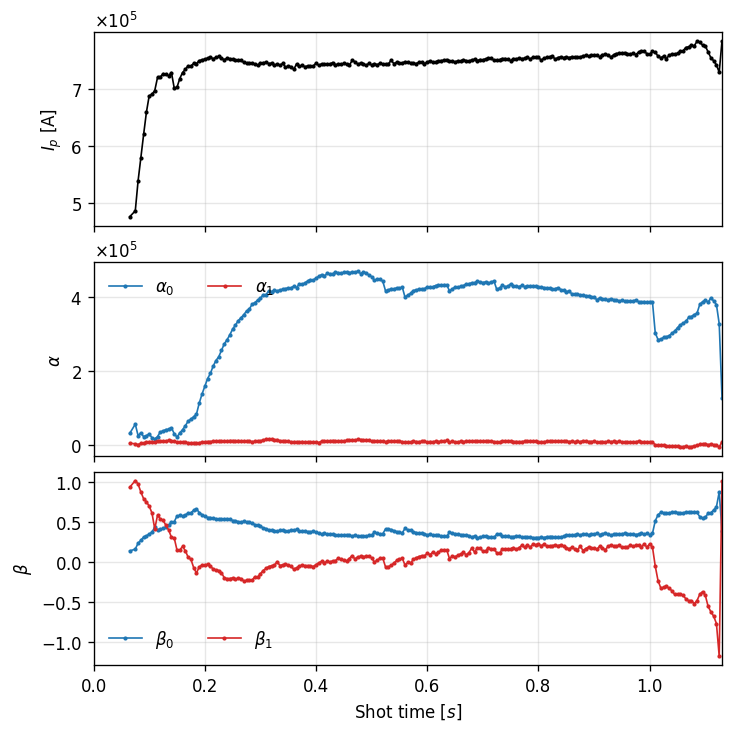

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(6, 6), dpi=120, sharex=True,
                          constrained_layout=True)

# --- Ip ---
ax = axes[0]
ax.plot(times, Ip, color='k', linewidth=1, marker='.', markersize=3)
ax.set_ylabel(r'$I_p$ [A]')
ax.ticklabel_format(axis='y', scilimits=(0, 0), useMathText=True)

# --- alpha ---
ax = axes[1]
ax.plot(times, alpha[:, 0], color='tab:blue', linewidth=1, marker='.', markersize=3, label=r"$\alpha_0$")
ax.plot(times, alpha[:, 1], color='tab:red', linewidth=1, marker='.', markersize=3, label=r"$\alpha_1$")
ax.set_ylabel(r'$\alpha$')
ax.ticklabel_format(axis='y', scilimits=(0, 0), useMathText=True)
ax.legend(loc="upper left", frameon=False, ncol=2)

# --- beta ---
ax = axes[2]
ax.plot(times, beta[:, 0], color='tab:blue', linewidth=1, marker='.', markersize=3, label=r"$\beta_0$")
ax.plot(times, beta[:, 1], color='tab:red', linewidth=1, marker='.', markersize=3, label=r"$\beta_1$")
ax.set_ylabel(r'$\beta$')
ax.set_xlabel(r'Shot time [$s$]')
ax.ticklabel_format(axis='y', scilimits=(0, 0), useMathText=True)
ax.legend(loc="lower left", frameon=False, ncol=2)

# --- shared styling ---
for ax in axes:
    ax.grid(alpha=0.3)
    ax.set_xlim(0, times[-1])

plt.show()

#### Initialise the equilibrium object and static solver
Here we initialise the equilibrium object, choosing the rectangular computational grid size and number of discretisation points.

We also load FreeGSNKE's static GS solver (can be used for forward and inverse solves but here we use for forward only). 

Note 1: It is not necessary to instantiate a new solver object when using it to solve for multiple different equilibria, as long as the integration domain, mesh grid, and tokamak required are identical. If you wish to modify these values for the same/different equilibria then you will need to instantiate new objects. 

In [6]:
# equilibrium object (note that both nx and ny have to be of the form 2**n + 1 with n being an integer)
eq = equilibrium_update.Equilibrium(
tokamak=tokamak,             # sets up the object with the MAST-U tokamak
Rmin=0.06, Rmax=2.0,         # computational grid radial limits (same as EFIT++)
Zmin=-2.2, Zmax=2.2,         # computational grid vertical limits (same as EFIT)
nx=65,                       # number of grid points in the radial direction
ny=129,                      # number of grid points in the vertical direction
psi=None                     # initial guess for the plasma flux (can provide one if available)
)

In [7]:
# static solver object (used for solving later on)
solver = GSstaticsolver.NKGSsolver(eq)  

#### Use FreeGSNKE to solve the static forward GS equation at each time slice

We are finally ready to solve the static forward GS problem using FreeGSNKE. This will be done sequentially in a loop over the times that we wish to simulate.

In [8]:
# extract efit time indices that we want to simulate
indices = []
for t in times_to_simulate:
    indices.append(np.argmin(np.abs(t - times)))
indices

[44, 45, 46, 47, 48]

In [9]:
# carry out the simulation and store some quantities of interest
from copy import deepcopy

static_equilibria = []
for i, t in zip(indices, times[indices]):

    print(f"-----Solving equilibrium for shot {shot} at time {t}-----")
    
    # initialise profile object
    profiles = jtor_update.Lao85(
        eq=eq,                                          # equilibrium object
        Ip=ip[i],                                       # total plasma current
        fvac=fvac[i],                                   # f vacuum parameter (R*Bt)
        alpha=alpha[i,:],                               # p' profile coefficients
        beta=beta[i,:],                                 # ff' profile coefficients
        alpha_logic=bool(alpha_logic[i]),               # logic parameters from above
        beta_logic=bool(beta_logic[i]),
    )
    
    # set coil currents in eq object
    if symmetric_machine:
        for key in currents_sym.keys():
            eq.tokamak.set_coil_current(key, currents_sym[key][i])
    else:
        for key in currents_nonsym.keys():
            eq.tokamak.set_coil_current(key, currents_nonsym[key][i])
     
    # carry out the forward solve
    eq.plasma_psi = eq.create_psi_plasma_default(gpars=(0.5,0.5,0,2)) # resets to default plasma flux guess
    solver.solve(eq=eq,
                 profiles=profiles,
                 constrain=None,
                 target_relative_tolerance=1e-7,
                )

    # store equilibria in a list
    static_equilibria.append(eq.create_auxiliary_equilibrium())


print("-----SIMULATIONS COMPLETE!-----")

-----Solving equilibrium for shot 45425 at time 0.29-----
Forward static solve SUCCESS. Tolerance 2.53e-08 (vs. requested 1.00e-07) reached in 25/100 iterations.
-----Solving equilibrium for shot 45425 at time 0.295-----
Forward static solve SUCCESS. Tolerance 1.25e-08 (vs. requested 1.00e-07) reached in 25/100 iterations.
-----Solving equilibrium for shot 45425 at time 0.3-----
Forward static solve SUCCESS. Tolerance 7.69e-08 (vs. requested 1.00e-07) reached in 23/100 iterations.
-----Solving equilibrium for shot 45425 at time 0.305-----
Forward static solve SUCCESS. Tolerance 5.21e-08 (vs. requested 1.00e-07) reached in 25/100 iterations.
-----Solving equilibrium for shot 45425 at time 0.31-----
Forward static solve SUCCESS. Tolerance 3.12e-08 (vs. requested 1.00e-07) reached in 24/100 iterations.
-----SIMULATIONS COMPLETE!-----


#### Select an equilibrium to work with

Choose a particular equilibrium to work with below by choosing the closest time slice to the one requested.

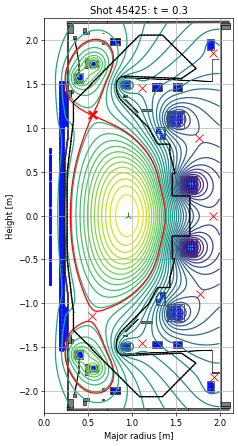

In [10]:
# CHOOSE THE EQUILIBRIUM YOU WANT
t_start = 0.300 # seconds

# finds starting equilibrium
idx = np.argmin(np.abs(times[indices] - t_start))
eq = deepcopy(static_equilibria[idx])
profiles = deepcopy(static_equilibria[idx]._profiles)

# plot the resulting equilbria
fig1, ax1 = plt.subplots(1, 1, figsize=(4, 8), dpi=60)
ax1.grid(True, which='both')
eq.plot(axis=ax1, show=False)
eq.tokamak.plot(axis=ax1, show=False)
ax1.set_xlim(0.0, 2.15)
ax1.set_ylim(-2.25, 2.25)
ax1.set_title(f"Shot {shot}: t = {t_start}")
plt.tight_layout()
plt.show()

#### Explore some properties of this equilibrium


In [11]:
print("---")
print("KEY SHAPE PARAMETERS")
print("---")

# Rin and Rout
RinRout = eq.innerOuterSeparatrix()
print(rf"Rin: {RinRout[0]} [m]")
print(rf"Rout: {RinRout[1]} [m]")
print("---")

# xpoints
primary_xpts = eq.xpt[0:2,0:2]
lower_xpt = primary_xpts[np.argmin(primary_xpts[:,1]),:]
upper_xpt = primary_xpts[np.argmax(primary_xpts[:,1]),:]
print(f"Lower x-point = {lower_xpt} [m].")
print(f"Upper x-point = {upper_xpt} [m].")
print("---")

# dr sep
dr_seps = eq.dr_sep(Z_level=0)
print(f"dr_sep_in = {dr_seps[0]} [m].")
print(f"dr_sep_out = {dr_seps[1]} [m].")
print("---")

# elongation
print(rf"Geometric elongation: {eq.geometricElongation()}")
print(rf"Geometric elongation (upper): {eq.geometricElongation_upper()}")
print(rf"Geometric elongation (lower): {eq.geometricElongation_lower()}")
print(rf"Effective elongation: {eq.effectiveElongation()}")
print("---")


# triangularity
print(rf"Triangularity: {eq.triangularity()}")
print(rf"Triangularity (upper): {eq.triangularity_upper()}")
print(rf"Triangularity (lower): {eq.triangularity_lower()}")
print("---")

# squareness
s_uo, s_ui, s_lo, s_li = eq.squareness()
print(rf"Squareness (upper outer): {s_uo}")
print(rf"Squareness (upper inner): {s_ui}")
print(rf"Squareness (lower outer): {s_lo}")
print(rf"Squareness (lower inner): {s_li}")
print("---")

# other things
print(rf"Aspect ratio: {eq.aspectRatio()}")
print(rf"LCFS circumference: {eq.separatrix_length()} [m]")
print(rf"LCFS area: {eq.separatrix_area()} [m^2]")
print(rf"Plasma volume: {eq.plasmaVolume()} [m^3]")
print(rf"Shafranov shift: {eq.shafranov_shift()} [m]")
print(rf"Magnetic axis location: {eq.magneticAxis()[0:2]} [m]")
print(rf"Geometric axis location: {eq.geometricAxis()} [m]")
print("---")

L = eq.closest_wall_point()
print(rf"Point on wall that is closest to the LCFS: {L[0]} [m]")
print(rf"Corresponding distance from point to LCFS: {L[1]} [m]")
print("---")

print(rf"Is this a limited plasma?: {eq.flag_limiter}")
print(rf"Does the core plasma boundary intersect the wall?: {eq.intersectsWall()}")
print("---")

---
KEY SHAPE PARAMETERS
---
Rin: 0.2980772439896407 [m]
Rout: 1.3822669032878447 [m]
---
Lower x-point = [ 0.54838144 -1.14584549] [m].
Upper x-point = [0.55050372 1.14356497] [m].
---
dr_sep_in = -0.0048665311235358 [m].
dr_sep_out = 0.0015874440837349013 [m].
---
Geometric elongation: 2.0576300454515195
Geometric elongation (upper): 2.103768032905541
Geometric elongation (lower): 2.011492057997498
Effective elongation: 1.8480509139000165
---
Triangularity: 0.48360061590935854
Triangularity (upper): 0.5190066345223625
Triangularity (lower): 0.44819459729635436
---
Squareness (upper outer): -0.06970959194234176
Squareness (upper inner): -0.254730228194801
Squareness (lower outer): -0.03144643628279929
Squareness (lower inner): -0.1417300506115637
---
Aspect ratio: 1.5503885034324805
LCFS circumference: 5.324145776368636 [m]
LCFS area: 1.7935651481445267 [m^2]
Plasma volume: 9.002923254050899 [m^3]
Shafranov shift: [ 0.11130689 -0.0250049 ] [m]
Magnetic axis location: [ 9.51553915e-01 

Calculating the plasma parameters is quite slow, need to fix this in FreeGSNKE. 

In [12]:
# print("---")
# print("KEY PLASMA PARAMETERS")
# print("---")

# print(rf"Plasma current: {eq.plasmaCurrent()} [A]")
# print("---")
# print(fr"Poloidal flux on magnetic axis: {eq.psi_axis} [Webers/2\pi]")
# print(fr"Poloidal flux on plasma boundary: {eq.psi_bndry} [Webers/2\pi]")
# print("---")
# print(rf"Poloidal beta (definition 1): {eq.poloidalBeta1()}")
# print(rf"Poloidal beta (definition 2): {eq.poloidalBeta2()}")
# print(rf"Poloidal beta (definition 3): {eq.poloidalBeta3()}")
# print(rf"Poloidal beta (definition 4): {eq.poloidalBeta4()}")
# print("---")
# print(rf"Toroidal beta (definition 1): {eq.toroidalBeta1()}")
# print(rf"Toroidal beta (definition 2): {eq.toroidalBeta2()}")
# print(rf"Toroidal beta (definition 3): {eq.toroidalBeta3()}")
# print(rf"Toroidal beta (definition 4): {eq.toroidalBeta4()}")
# print("---")
# print(rf"Normalised total beta: {eq.normalised_total_Beta()}")
# print("---")
# print(fr"Plasma internal inductance (definition 1): {eq.internalInductance1()}")
# print(fr"Plasma internal inductance (definition 2): {eq.internalInductance2()}")
# print(fr"Plasma internal inductance (definition 3): {eq.internalInductance3()}")
# print(fr"Plasma internal inductance (definition 4): {eq.internalInductance4()}")
# print(fr"Plasma internal inductance (definition 5): {eq.internalInductance5()}")

#### Calculate state space model quantites

Instantiate the nonlinear solver object in order to calculate the state space model matrices and growth rate parameters (and stability margin) for this equilibrium.

Next you need to choose the properties you want for the state-space model. I would encourage you to read the Example10 notebook on the FreeGSNKE repo to see the different settings below. It basically determines how many passive structure modes you wish to use in the model - below I've selected to use all the modes (which is a bit slow). 

In [13]:
from freegsnke import nonlinear_solve

state_space_model = nonlinear_solve.nl_solver(
    eq=eq, 
    profiles=profiles,
    GSStaticSolver=solver,
    plasma_resistivity=2e-7,      # set an appropriate plasma resistivity (goes into the Ip equation)
    # min_dIy_dI=1e-5,            # set between [0,1]
    # threshold_dIy_dI=1,         # set between [0,1]
    # max_mode_frequency=1e10,    # set between [0,inf]
    fix_n_vessel_modes=150,       # select number of passive structure modes
    # custom_coil_resist=coil_R,    # use calibrated resistance matrix for active coils
    # custom_self_ind=coil_M,       # use calibrated inductance matrix for active coils
    n_linearization_workers=10,   # set >1 to parallelise Jacobian construction (i.e. number of cores to use)
    )

-----
Checking that the provided 'eq' and 'profiles' are a GS solution...
Forward static solve SUCCESS. Tolerance 2.59e-09 (vs. requested 1.00e-08) reached in 2/100 iterations.
-----
Instantiating nonlinear solver objects...
done.
-----
Identifying mode selection criteria...
      'fix_n_vessel_modes' option selected --> passive structure modes that couple most to the strongest passive structure mode are being selected.
-----
Initial mode selection:
   Active coils
      total selected = 13 (out of 13)
   Passive structures
      150 selected using 'fix_n_vessel_modes'
   Total number of modes = 163 (13 active coils + 150 passive structures)
      (Note: some additional modes may be removed after Jacobian calculation if 'mode_removal=True')
-----
Building the 3563 x 164 Jacobian (dIy/dI) of plasma current density (inside the LCFS) with respect to all metal currents and the total plasma current.
Building the 3563 x 4 Jacobian (dIy/dtheta) of plasma current density (inside the LCFS) with

In [14]:
print(f"Deformable GR = {state_space_model.linearised_sol.growth_rates}")
print(f"Deformable GR (without Ip) = {state_space_model.linearised_sol.growth_rates_const_Ip}")
print(f"Inductive stability margin = {state_space_model.linearised_sol.stability_margin}")
print(f"Leuer parameter = {state_space_model.Leuer_metals_stab_over_active_destab}")

Deformable GR = [71.26735167+0.j]
Deformable GR (without Ip) = [71.78031476]
Inductive stability margin = [0.77191674+0.j]
Leuer parameter = 1.8267573406989148


Now let's extract the matrices used in the FreeGSNKE state space model. Below is a (lengthy) recap of the equations that we use:


---

Assume we have solved the Grad-Shafranov equation and have obtained an equilibrium. From this we can extract the plasma current density discretised over the spatial domain (whose points are only non-zero inside the LCFS, so we mask points outside the limiter to save memory):

\begin{equation*}
    \vec{I}_y := \vec{I}_y^{GS} (\vec{I}_m, I_p, \vec{\theta}).
    \tag{1}
\end{equation*}

This is a function of the: 
- currents in the metal conductors $\vec{I}_m$ (i.e. the active coils and passive  - or passive modes if we've done the decomposition).
- plasma current $I_p$.
- parameters $\vec{\theta}$ used to define the plasma current density profiles (i.e. $p'(\psi_n)$ and $FF'(\psi_n)$). 

In order to estimate the instability timescales/growth rates of this plasma, we will need to define (and then linearise) the coupled **circuit** and **plasma** equations. 

**Circuit equations**: 

These equations govern the flow of current in the active coils and passive structures (while being coupled to the currents in the plasma):

\begin{equation}
    M_{m,m} \vec{\dot{I}}_m + M_{m,y} \vec{\dot{I}}_y + R_{m,m} \vec{I}_m = \vec{V}_m
    \tag{2}
\end{equation}

- $M_{m,m}$ is the symmetric matrix of mutual inductances between all of the metals. 
- $M_{m,y}$ is the matrix of mutual inductances between all of the metals and the discretised plasma current density. 
- $R_{m,m}$ is the diagonal matrix of resistances in the metals.
- $V_m$ is the vector of voltages applied to the metals (note: these are non-zero for the active coils only).
- Note that the dots indicate time derivatives. 

**Plasma equation**: 

This equation governs the flow of current in the plasma (while being coupled to the currents in the metals):

\begin{equation}
    \frac{\vec{I}_y^T}{I_p} \left( M_{y,y} \vec{\dot{I}}_y + M_{y,m} \vec{\dot{I}}_m + R_{y,y} \vec{I}_y \right) = \vec{0}
    \tag{3}
\end{equation}

- $M_{y,m} = M_{m,y}^{T}$ (from above).
- $R_{y,y} = 2 \pi \sigma_p \hat{R} /dA$ is the diagonal matrix of resistances for each plasma element.
    - $\sigma_p$ is the assigned plasma resistivity. 
    - $\hat{R}$ is a matrix storing the radial position of each plasma element.
    - $dA$ is the area of each plasma element.


**Linearisation of discretised plasma current density**:

To simplify these equations, we linearise equation (1) around the current GS equilibrium such that:

\begin{equation}
    \dot{\vec{I}_y} \approx \frac{\partial \vec{I}_y}{\partial \vec{I}_m} \Bigg|_{GS} \dot{\vec{I}}_m + \frac{\partial \vec{I}_y}{\partial I_p}\Bigg|_{GS} \dot{I}_p + \frac{\partial \vec{I}_y}{\partial \vec{\theta}}\Bigg|_{GS} \dot{\vec{\theta}}.
    \tag{4}
\end{equation}

The partial derivative terms (i.e. the Jacobians) are calculated in FreeGSNKE using finite differences. The use of these Jacobians is what makes this a **deformable** growth rate model. 

We can plug this equation into both (2) and (3) and re-arrange:

\begin{align}
    \left( M_{m,m} + M_{m,y} \frac{\partial \vec{I}_y}{\partial \vec{I}_m} \Bigg|_{GS} \right) \vec{\dot{I}}_m + M_{m,y} \frac{\partial \vec{I}_y}{\partial I_p}\Bigg|_{GS} \dot{I_p} + R_{m,m} \vec{I}_m + M_{m,y} \frac{\partial \vec{I}_y}{\partial \vec{\theta}}\Bigg|_{GS} \dot{\vec{\theta}} = \vec{V}_m \tag{5} \\
    \frac{\vec{I}_y}{I_p} \left[ \left( M_{y,y} \frac{\partial \vec{I}_y}{\partial \vec{I}_m} \Bigg|_{GS} + M_{y,m} \right) \dot{\vec{I}}_m  + M_{y,y} \frac{\partial \vec{I}_y}{\partial I_p}\Bigg|_{GS} \dot{I_p} + R_{y,y} \vec{I}_y + M_{y,y} \frac{\partial \vec{I}_y}{\partial \vec{\theta}}\Bigg|_{GS} \dot{\vec{\theta}} \right] = \vec{0}. \tag{6}
\end{align}

Next, we need to write this in state matrix form. For this, we need to remove the dependence of equation (6) on the denominator $I_p$ by introducing two terms:
- $\hat{\vec{I}}_y = \vec{I}_y / I_p$ is the normalised discretised plasma current density over the spatial domain.
- $R_p = \hat{\vec{I}}_y^{T} R_{y,y} \hat{\vec{I}}_y$ is the "lumped" plasma resistance.

This results in the state matrix system $\vec{M} \dot{\vec{x}} + \vec{R} \vec{x} = \vec{c}$:

\begin{equation*}
\begin{aligned}
\left[\begin{array}{cc}
 M_{m,m} + M_{m,y} \frac{\partial \vec{I}_y}{\partial \vec{I}_m} \Bigg|_{GS} & M_{m,y} \frac{\partial \vec{I}_y}{\partial I_p}\Bigg|_{GS} \\ 
\frac{\hat{\vec{I}}_y}{R_p} \left( M_{y,y} \frac{\partial \vec{I}_y}{\partial \vec{I}_m} \Bigg|_{GS} + M_{y,m} \right) & \frac{\hat{\vec{I}}_y}{R_p} M_{y,y} \frac{\partial \vec{I}_y}{\partial I_p}\Bigg|_{GS}
\end{array}\right]
\left[\begin{array}{c}
\dot{\vec{I}}_m \\ 
\dot{I}_p
\end{array}\right] +

\left[\begin{array}{cc}
R_{m,m} & 0 \\ 
0 & 1
\end{array}\right]
\left[\begin{array}{c}
\vec{I}_m \\ 
I_p
\end{array}\right]

&=
\left[\begin{array}{c}
\vec{V}_m \\ 
0 
\end{array}\right]
-
\left[\begin{array}{c}
M_{m,y} \frac{\partial \vec{I}_y}{\partial \vec{\theta}}\Bigg|_{GS} \dot{\vec{\theta}} \\ 
\frac{\hat{\vec{I}}_y}{R_p} M_{y,y} \frac{\partial \vec{I}_y}{\partial \vec{\theta}}\Bigg|_{GS} \dot{\vec{\theta}}
\end{array}\right].

\end{aligned}
\end{equation*}

Note that in the next section we use $\vec{I}_d$ to represent the vector of active coil and passive *mode* currents such that $\vec{I}_m = P \vec{I}_d$ (where $P$ is the eigenmode decomposition matrix - see original freegsnke paper for details or Example10 notebook). 

Also note that you can ignore the effect of the final term on the right hand side of the equation (involving Jacobians wrt the plasma parameters) if so desired - these effects are thought to be small. 


**State space model**:

This can be written as:

$$ L_* \frac{d \vec{x}}{dt} + R \vec{x} = \vec{u} $$

where:
- $\vec{x}$ is the state space vector. 
- $L_*$ is the modified inductance matrix.
- $R$ is the resistance matrix. 
- $u$ is the control (voltage) vector. 

Let's look at the state space vector, which is made up of the:
- 13 active coil currents [A] (PC current should be zero or close to it). 
- 150 passive structure currents [A] (assuming all modes being used). 
- plasma current [kA] (single number).

In [15]:
# state space vector
x = state_space_model.currents_vec

# ordering of the actives, passives, and Ip in the vector
ordering = tokamak.coil_names

In [33]:
# mutual inductances between all metals
Mmm = state_space_model.evol_metal_curr.coil_self_ind
print(Mmm.shape)

# resistances for all metals
Rmm = state_space_model.evol_metal_curr.coil_resist
print(Rmm.shape)

# mutual inductances between all metals and plasma grid elements
Mmy = state_space_model.evol_metal_curr.Mey_matrix
print(Mmy.shape)

# normalised plasma current density (Iy / Ip), sums to 1, defined over the same 3563 plasma grid points as Iy
hatIy = state_space_model.hatIy
print(hatIy.shape)

# Myy @ hatIy, precomputed by FreeGSNKE without ever forming the full (3563 x 3563) Myy matrix
# (Myy itself is only ever built/stored on a small adaptive sub-domain around the plasma - see state_space_model.handleMyy)
Myy_hatIy = state_space_model.Myy_hatIy0
print(Myy_hatIy.shape)

(163, 163)
(163,)
(163, 3563)
(3563,)
(3563,)


In [34]:
# mode transformation matrix (if number of passive modes reduced)
P = state_space_model.linearised_sol.P
P.shape

(163, 163)

In [35]:
# Jacobian of plasma current density wrt mode currents (i.e. the linearisation!)
dIydId = state_space_model.linearised_sol.dIydI[:,0:-1]
print(dIydId.shape)

# Jacobian of plasma current density wrt plasma current (i.e. the linearisation!)
dIydIp = state_space_model.linearised_sol.dIydI[:,-1] / state_space_model.plasma_norm_factor
print(dIydIp.shape)

(3563, 163)
(3563,)


In [36]:
# diagonal of R_yy, the plasma resistance matrix (2*pi*sigma_p*Rhat/dA), one entry per plasma grid point
Ryy = state_space_model.plasma_resistance_1d
print(Ryy.shape)

# lumped plasma resistance: Rp = hatIy^T @ Ryy @ hatIy
Rp = np.dot(Ryy, hatIy**2)
print(Rp)

(3563,)
8.160695334414184e-07


#### Assemble $L_*$ and $R$

Substituting $\vec{I}_m = P \vec{I}_d$ into the block matrix above (so that the state vector becomes $\vec{x} = (\vec{I}_d, I_p)^T$, matching `state_space_model.currents_vec`) gives:

$$
L_* = \left[\begin{array}{cc}
M_{m,m}P + M_{m,y}A & M_{m,y}B \\
\dfrac{1}{R_p}\left(\hat{\vec{I}}_y^{T} M_{y,y} A + \hat{\vec{I}}_y^{T} M_{y,m}P\right) & \dfrac{1}{R_p}\hat{\vec{I}}_y^{T} M_{y,y} B
\end{array}\right],
\qquad
R = \left[\begin{array}{cc} R_{m,m}P & 0 \\ 0 & 1 \end{array}\right]
$$

where $A = \partial \vec{I}_y/\partial \vec{I}_d$ (`dIydId`) and $B = \partial \vec{I}_y/\partial I_p$ (`dIydIp`).

Two things to watch for when using the quantities already extracted above:

- $\hat{\vec I}_y^{T} M_{y,y} = (M_{y,y}\hat{\vec I}_y)^{T}$ since $M_{y,y}$ is symmetric, so both bottom-row terms can be built from the vector `Myy_hatIy0` alone (`Myy_hatIy0 @ A` and `Myy_hatIy0 @ B`) - we never need the full (3563 x 3563) $M_{y,y}$ matrix.

In [37]:
n = P.shape[0]   # number of independent metal current modes (13 active coils + 150 selected passive modes)

# L* blocks
L_dd = Mmm @ P + Mmy @ dIydId                       # (n, n)
L_dp = Mmy @ dIydIp                                 # (n,)
L_pd = (Myy_hatIy @ dIydId + (Mmy @ hatIy) @ P) / Rp   # (n,)
L_pp = (Myy_hatIy @ dIydIp) / Rp                   # scalar

L_star = np.zeros((n + 1, n + 1))
L_star[:n, :n] = L_dd
L_star[:n, -1] = L_dp
L_star[-1, :n] = L_pd
L_star[-1, -1] = L_pp

# R blocks
R = np.zeros((n + 1, n + 1))
R[:n, :n] = np.diag(Rmm) @ P
R[-1, -1] = 1.0

L_star.shape, R.shape

((164, 164), (164, 164))

#### Sanity check against FreeGSNKE's own growth rates

$L_* \dot{\vec x} + R \vec x = \vec u$ implies $\dot{\vec x} = -L_*^{-1}R\,\vec x + L_*^{-1}\vec u$, so the eigenvalues of $-L_*^{-1}R$ are the system's characteristic (growth) rates. 

This should match `state_space_model.linearised_sol.growth_rates` (up to which of the eigenvalues are unstable/positive), independently of the internal basis/scaling FreeGSNKE itself uses to build `linearised_sol.Mmatrix`.

Note that FreeGSNKE internally calculates the GRs using $-R^{-1} L_*$ as it's more numerically stable so we'll do that here. 

In [38]:
# P inverse
Pm1 = state_space_model.evol_metal_curr.Pm1

# find R^{-1} @ L* 
Rinv_L = np.zeros_like(L_star)
Rinv_L[:n, :] = (Pm1 @ np.diag(1.0 / Rmm)) @ L_star[:n, :]   # R_dd^-1 @ [L_dd | L_dp]
Rinv_L[-1, :] = L_star[-1, :]                                # R_pp = 1, so this row is unchanged

# eigenvalues of R^-1 L* are reciprocals of eigenvalues of L*^-1 R, so growth_rate = -1/eigenvalue
timescales = -np.linalg.eigvals(Rinv_L)
growth_rates = np.sort(1.0 / timescales[timescales.real > 0].real)

print("Growth rates from L_*, R assembled here:", growth_rates)
print("Growth rates from state_space_model:    ", state_space_model.linearised_sol.growth_rates.real)

Growth rates from L_*, R assembled here: [71.26735167]
Growth rates from state_space_model:     [71.26735167]
